In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from filterpy.kalman import ExtendedKalmanFilter
from filterpy.common import Q_discrete_white_noise
import xgboost as xgb
from sklearn.metrics import classification_report
from sklearn.calibration import CalibratedClassifierCV

In [ ]:
pip install filterpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 3.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for filterpy: filename=filterpy-1.4.5-py3-none-any.whl size=110460 sha256=1252b4c2b5ee6cfaeff8a349deb501518437f2f3ec8fefb69e01f1e4004cf745
  Stored in directory: /root/.cache/pip/wheels/77/bf/4c/b0c3f4798a0166668752312a67118b27a3cd341e13ac0ae6ee
Successfully built filterpy


In [ ]:
def generate_texbat_proxy_log(start_time, duration_seconds=3600, spoofing_start=1800):
    time_index = [start_time + timedelta(seconds=i) for i in range(duration_seconds)]
    cn0 = np.random.normal(45, 1.5, duration_seconds)
    doppler = 1500 * np.sin(np.linspace(0, 2*np.pi, duration_seconds)) + np.random.normal(0, 5, duration_seconds)
    label = np.zeros(duration_seconds)

    if spoofing_start < duration_seconds:
        drag_off_duration = min(120, duration_seconds - spoofing_start)
        spoofing_end = spoofing_start + drag_off_duration

        cn0[spoofing_start:spoofing_end] -= np.linspace(0, 15, drag_off_duration)
        if spoofing_end < duration_seconds:
            cn0[spoofing_end:] -= 15 + np.random.normal(0, 2, duration_seconds - spoofing_end)

        doppler[spoofing_start:] += np.linspace(0, 500, duration_seconds - spoofing_start)
        label[spoofing_start:] = 1

    df = pd.DataFrame({'time_tag': time_index, 'C_N0': cn0, 'doppler_hz': doppler, 'label': label})
    df['Kp'] = np.random.uniform(1, 3, duration_seconds)
    return df

In [ ]:
base_time = datetime.now()
df_mission_1 = generate_texbat_proxy_log(base_time, duration_seconds=1800, spoofing_start=500)
df_mission_2 = generate_texbat_proxy_log(base_time + timedelta(seconds=1800), duration_seconds=1800, spoofing_start=1200)

df_final = pd.concat([df_mission_1, df_mission_2], ignore_index=True)
print(f"Data: {len(df_final)} class: {dict(df_final['label'].value_counts())}")

Data: 3600 class: {1.0: np.int64(1900), 0.0: np.int64(1700)}


In [ ]:
def hx_doppler(x): return np.array([x[0]])
def H_jacobian_doppler(x): return np.array([[1., 0.]])

ekf = ExtendedKalmanFilter(dim_x=2, dim_z=1)
ekf.F = np.array([[1., 1.0], [0., 1.]])
ekf.x = np.array([[0.], [0.]])
ekf.P *= 500.
ekf.Q = Q_discrete_white_noise(dim=2, dt=1.0, var=0.1)
ekf.R = np.array([[5.0]])

residuals = []

In [ ]:
for z in df_final['doppler_hz'].values:
    ekf.predict()
    ekf.update(np.array([z]), HJacobian=H_jacobian_doppler, Hx=hx_doppler)
    residuals.append(ekf.y[0].item())

In [ ]:
df_final['EKF_residual'] = residuals
df_final['EKF_residual_abs'] = np.abs(df_final['EKF_residual'])
print("   - EKF residual özellikleri sisteme entegre edildi.")

   - EKF residual özellikleri sisteme entegre edildi.


In [ ]:
window_size = 5
df_final['EKF_rolling_mean'] = df_final['EKF_residual_abs'].rolling(window=window_size, min_periods=1).mean()
df_final['EKF_rolling_std'] = df_final['EKF_residual_abs'].rolling(window=window_size, min_periods=1).std().fillna(0)
df_final['EKF_residual_diff'] = df_final['EKF_residual_abs'].diff().fillna(0)

In [ ]:
features = ['doppler_hz', 'C_N0', 'Kp', 'EKF_residual_abs', 'EKF_rolling_mean', 'EKF_rolling_std', 'EKF_residual_diff']
target = 'label'

In [ ]:
df_clean = df_final.dropna(subset=features + [target]).copy()

In [ ]:
split_index = int(len(df_clean) * 0.75)
X_train, X_test = df_clean[features].iloc[:split_index], df_clean[features].iloc[split_index:]
y_train, y_test = df_clean[target].iloc[:split_index], df_clean[target].iloc[split_index:]

In [ ]:
model = xgb.XGBClassifier(n_estimators=150, max_depth=6, learning_rate=0.1, tree_method='hist', random_state=42)
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=150,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
calibrated_model = CalibratedClassifierCV(model, method='sigmoid', cv='prefit')
calibrated_model.fit(X_test, y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


CalibratedClassifierCV(cv='prefit',
                       estimator=XGBClassifier(base_score=None, booster=None,
                                               callbacks=None,
                                               colsample_bylevel=None,
                                               colsample_bynode=None,
                                               colsample_bytree=None,
                                               device=None,
                                               early_stopping_rounds=None,
                                               enable_categorical=False,
                                               eval_metric=None,
                                               feature_types=None,
                                               feature_weights=None, gamma=None,
                                               grow_policy=None,
                                               importance_type=None,
                                               interaction_constraints=None,
                                               learning_rate=0.1, max_bin=None,
                                               max_cat_threshold=None,
                                               max_cat_to_onehot=None,
                                               max_delta_step=None, max_depth=6,
                                               max_leaves=None,
                                               min_child_weight=None,
                                               missing=nan,
                                               monotone_constraints=None,
                                               multi_strategy=None,
                                               n_estimators=150, n_jobs=None,
                                               num_parallel_tree=None, ...))

In [ ]:
y_pred = calibrated_model.predict(X_test)
y_proba = calibrated_model.predict_proba(X_test)

In [ ]:
def calculate_ece(y_true, y_proba, n_bins=10):
    confidences = np.max(y_proba, axis=1)
    predictions = np.argmax(y_proba, axis=1)
    accuracies = predictions == y_true
    ece = 0.0
    bins = np.linspace(0, 1, n_bins + 1)
    for i in range(n_bins):
        in_bin = (confidences > bins[i]) & (confidences <= bins[i+1])
        prop_in_bin = np.mean(in_bin)
        if prop_in_bin > 0:
            ece += np.abs(np.mean(confidences[in_bin]) - np.mean(accuracies[in_bin])) * prop_in_bin
    return ece

In [ ]:
ece_score = calculate_ece(y_test.values, y_proba)

In [ ]:
print(classification_report(y_test, y_pred))
print(f">> ECE expected calibration error: {ece_score:.4f}")

              precision    recall  f1-score   support

         0.0       0.89      1.00      0.94       300
         1.0       1.00      0.94      0.97       600

    accuracy                           0.96       900
   macro avg       0.94      0.97      0.95       900
weighted avg       0.96      0.96      0.96       900

>> ECE expected calibration error: 0.0067


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving channel.mat to channel.mat


In [ ]:
import scipy.io as sio

# Colab'a yüklediğin dosyanın adını buraya yaz
mat_file_path = 'channel.mat'

print(f">> {mat_file_path} dosyası kırılıyor...")
try:
    mat_contents = sio.loadmat(mat_file_path)

    print("\n>> DOSYA İÇİNDEKİ DEĞİŞKENLER (KEYS):")
    for key in mat_contents.keys():
        # MATLAB'in kendi gizli meta verilerini (__header__ vs.) atla
        if not key.startswith('__'):
            veri_tipi = type(mat_contents[key])
            boyut = mat_contents[key].shape if hasattr(mat_contents[key], 'shape') else "Bilinmiyor"
            print(f" - {key}: {veri_tipi} | Boyut: {boyut}")

except Exception as e:
    print(f"Hata: Dosya okunamadı. Detay: {e}")

>> channel.mat dosyası kırılıyor...

>> DOSYA İÇİNDEKİ DEĞİŞKENLER (KEYS):
 - channel: <class 'numpy.ndarray'> | Boyut: (14, 31892)


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving channel-2.mat to channel-2.mat


In [ ]:
import scipy.io as sio

# Colab'a yüklediğin dosyanın adını buraya yaz
mat_file_path = 'channel-2.mat'

print(f">> {mat_file_path} dosyası kırılıyor...")
try:
    mat_contents = sio.loadmat(mat_file_path)

    print("\n>> DOSYA İÇİNDEKİ DEĞİŞKENLER (KEYS):")
    for key in mat_contents.keys():
        # MATLAB'in kendi gizli meta verilerini (__header__ vs.) atla
        if not key.startswith('__'):
            veri_tipi = type(mat_contents[key])
            boyut = mat_contents[key].shape if hasattr(mat_contents[key], 'shape') else "Bilinmiyor"
            print(f" - {key}: {veri_tipi} | Boyut: {boyut}")

except Exception as e:
    print(f"Hata: Dosya okunamadı. Detay: {e}")

>> channel-2.mat dosyası kırılıyor...

>> DOSYA İÇİNDEKİ DEĞİŞKENLER (KEYS):
 - channel: <class 'numpy.ndarray'> | Boyut: (14, 31203)


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving navsol.mat to navsol.mat


In [ ]:
import scipy.io as sio

# Colab'a yüklediğin dosyanın adını buraya yaz
mat_file_path = 'navsol.mat'

print(f">> {mat_file_path} dosyası kırılıyor...")
try:
    mat_contents = sio.loadmat(mat_file_path)

    print("\n>> DOSYA İÇİNDEKİ DEĞİŞKENLER (KEYS):")
    for key in mat_contents.keys():
        # MATLAB'in kendi gizli meta verilerini (__header__ vs.) atla
        if not key.startswith('__'):
            veri_tipi = type(mat_contents[key])
            boyut = mat_contents[key].shape if hasattr(mat_contents[key], 'shape') else "Bilinmiyor"
            print(f" - {key}: {veri_tipi} | Boyut: {boyut}")

except Exception as e:
    print(f"Hata: Dosya okunamadı. Detay: {e}")

>> navsol.mat dosyası kırılıyor...

>> DOSYA İÇİNDEKİ DEĞİŞKENLER (KEYS):
 - navsol: <class 'numpy.ndarray'> | Boyut: (12, 2115)


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving navsol-2.mat to navsol-2.mat


In [ ]:
import scipy.io as sio

# Colab'a yüklediğin dosyanın adını buraya yaz
mat_file_path = 'navsol-2.mat'

print(f">> {mat_file_path} dosyası kırılıyor...")
try:
    mat_contents = sio.loadmat(mat_file_path)

    print("\n>> DOSYA İÇİNDEKİ DEĞİŞKENLER (KEYS):")
    for key in mat_contents.keys():
        # MATLAB'in kendi gizli meta verilerini (__header__ vs.) atla
        if not key.startswith('__'):
            veri_tipi = type(mat_contents[key])
            boyut = mat_contents[key].shape if hasattr(mat_contents[key], 'shape') else "Bilinmiyor"
            print(f" - {key}: {veri_tipi} | Boyut: {boyut}")

except Exception as e:
    print(f"Hata: Dosya okunamadı. Detay: {e}")

>> navsol-2.mat dosyası kırılıyor...

>> DOSYA İÇİNDEKİ DEĞİŞKENLER (KEYS):
 - navsol: <class 'numpy.ndarray'> | Boyut: (12, 2100)


In [ ]:
import scipy.io as sio
import numpy as np

# Yüklediğin dosyanın adı. Eğer farklı bir isimle yüklendiyse burayı değiştir.
mat_file = 'channel.mat'

print(f">> {mat_file} Otopsisi Başlıyor...\n")
try:
    mat_data = sio.loadmat(mat_file)
    for key, val in mat_data.items():
        if not key.startswith('__'): # MATLAB'in gizli sistem dosyalarını atla
            print(f"[{key}] -> Tip: {type(val)} | Boyut: {np.shape(val)}")

            # İçinde veri olan matrislerin ilk 5 elemanına sız
            if isinstance(val, np.ndarray) and val.size > 0:
                print(f"    Örnek Veri: {val.flatten()[:5]}")
            print("-" * 50)

except FileNotFoundError:
    print(f"HATA: '{mat_file}' bulunamadı. Sol panelden Colab'a yüklediğine emin misin?")
except Exception as e:
    print(f"HATA: Beklenmeyen bir çöküş yaşandı: {e}")

>> channel.mat Otopsisi Başlıyor...

[channel] -> Tip: <class 'numpy.ndarray'> | Boyut: (14, 31892)
    Örnek Veri: [0. 0. 0. 0. 0.]
--------------------------------------------------


In [ ]:
import scipy.io as sio
import pandas as pd
import numpy as np

def texbat_mat_to_df(mat_path, label):
    # 1. MATLAB dosyasını yükle
    data = sio.loadmat(mat_path)

    # 2. 'channel' anahtarındaki matrisi al ve transpose (devrik) yap
    # (Teksaslıların notunda belirttiği gibi)
    raw_matrix = data['channel'].T

    # 3. İlgili sütunları ayıkla (0: Time, 1: PRN, 2: CN0, 3: Doppler)
    df = pd.DataFrame(raw_matrix[:, :4], columns=['time_tag', 'PRN', 'C_N0', 'doppler_hz'])

    # 4. Etiketi ekle (0: Temiz, 1: Saldırı)
    df['label'] = label

    # 5. Mimari uyumu için Kp (Uzay Havası) proxy'si ekle
    df['Kp'] = np.random.uniform(1, 3, len(df))

    return df

# DOSYALARI DÖNÜŞTÜR (Dosya isimlerini yüklediğin şekilde güncelle)
print(">> Gerçek veriler MLOps boru hattına çekiliyor...")

# Temiz Veri (label=0)
df_clean = texbat_mat_to_df('channel.mat', label=0) # cleanStatic/channel.mat

# Saldırı Verisi (label=1)
# Buraya ds2 içerisinden çıkan channel-2.mat gibi isimlendirdiğin dosyayı yaz
df_attack = texbat_mat_to_df('channel-2.mat', label=1)

# BİRLEŞTİRME (Zaman sızıntısı olmaması için alt alta ekliyoruz)
df_real_final = pd.concat([df_clean, df_attack], ignore_index=True)

print(f"\n>> DÖNÜŞÜM TAMAMLANDI.")
print(f"Toplam Satır: {len(df_real_final)}")
print(f"Sınıf Dağılımı:\n{df_real_final['label'].value_counts()}")
print("\nTablo Önizleme (İlk 5 Satır):")
print(df_real_final.head())

>> Gerçek veriler MLOps boru hattına çekiliyor...

>> DÖNÜŞÜM TAMAMLANDI.
Toplam Satır: 63095
Sınıf Dağılımı:
label
0    31892
1    31203
Name: count, dtype: int64

Tablo Önizleme (İlk 5 Satır):
   time_tag       PRN    C_N0  doppler_hz  label        Kp
0       0.0  0.200569  9999.0         0.0      0  2.747308
1       0.0  0.200569  9999.0         0.0      0  1.298395
2       0.0  0.200569  9999.0         0.0      0  1.111736
3       0.0  0.200569  9999.0         0.0      0  1.823344
4       0.0  0.200569  9999.0         0.0      0  2.257892


In [ ]:
import scipy.io as sio
import numpy as np

# Dosyayı yükle
data = sio.loadmat('channel.mat')
raw_matrix = data['channel'] # Transpose yapmadan önce (14, 31892)

print(">> SÜTUN ANALİZİ BAŞLADI (14 Satırın Karakteristiği):\n")
for i in range(raw_matrix.shape[0]):
    row_data = raw_matrix[i, :]
    print(f"Satır {i}: Mean={np.mean(row_data):.2f} | Std={np.std(row_data):.2f} | Max={np.max(row_data):.2f}")

>> SÜTUN ANALİZİ BAŞLADI (14 Satırın Karakteristiği):

Satır 0: Mean=0.00 | Std=0.00 | Max=0.00
Satır 1: Mean=227.90 | Std=131.52 | Max=455.60
Satır 2: Mean=2189.24 | Std=1944.69 | Max=9999.00
Satır 3: Mean=450205.94 | Std=112101.42 | Max=478334.00
Satır 4: Mean=0.56 | Std=0.29 | Max=0.97
Satır 5: Mean=-294.58 | Std=1966.17 | Max=2636.33
Satır 6: Mean=63114.62 | Std=519826.17 | Max=1512994.14
Satır 7: Mean=23394501.64 | Std=7682894.73 | Max=36956031.15
Satır 8: Mean=46.75 | Std=4.75 | Max=52.71
Satır 9: Mean=0.94 | Std=0.23 | Max=1.00
Satır 10: Mean=0.00 | Std=0.02 | Max=1.00
Satır 11: Mean=5.96 | Std=0.25 | Max=6.00
Satır 12: Mean=1.86 | Std=4.55 | Max=13.00
Satır 13: Mean=32.93 | Std=42.68 | Max=138.00


In [ ]:
import scipy.io as sio
import pandas as pd
import numpy as np

def texbat_mat_to_df_v2(mat_path, label):
    data = sio.loadmat(mat_path)
    raw_matrix = data['channel'] # Transpose yapmadan (14, N) formatında alıyoruz

    # Keşfettiğimiz doğru satırları çekiyoruz
    # Satır 3: Zaman, Satır 5: Doppler, Satır 8: C/N0
    df = pd.DataFrame({
        'time_tag': raw_matrix[3, :],
        'doppler_hz': raw_matrix[5, :],
        'C_N0': raw_matrix[8, :],
        'label': label
    })

    # Mimari uyumu için Kp (Uzay Havası) proxy'si
    df['Kp'] = np.random.uniform(1, 3, len(df))

    return df

# DOSYALARI DÖNÜŞTÜR
print(">> Gerçek TEXBAT verileri yeni şifreyle çözülüyor...")

# 1. Temiz Veri (cleanStatic/channel.mat)
df_clean = texbat_mat_to_df_v2('channel.mat', label=0)

# 2. Saldırı Verisi (ds2/channel.mat - Colab'daki ismini kontrol et, channel-2.mat yapmış olabilirsin)
df_attack = texbat_mat_to_df_v2('channel-2.mat', label=1)

# BİRLEŞTİRME
df_real_final = pd.concat([df_clean, df_attack], ignore_index=True).dropna()

print(f"\n>> DÖNÜŞÜM BAŞARILI.")
print(f"Toplam Gerçek Veri: {len(df_real_final)} satır.")
print(f"C/N0 Ortalaması: {df_real_final['C_N0'].mean():.2f} dB-Hz")
print(f"Doppler Standart Sapması: {df_real_final['doppler_hz'].std():.2f} Hz")

>> Gerçek TEXBAT verileri yeni şifreyle çözülüyor...

>> DÖNÜŞÜM BAŞARILI.
Toplam Gerçek Veri: 63095 satır.
C/N0 Ortalaması: 47.64 dB-Hz
Doppler Standart Sapması: 1961.88 Hz


In [ ]:
from filterpy.kalman import ExtendedKalmanFilter
from filterpy.common import Q_discrete_white_noise
import xgboost as xgb
from sklearn.metrics import classification_report
from sklearn.calibration import CalibratedClassifierCV

def hx_doppler(x): return np.array([x[0]])
def H_jacobian_doppler(x): return np.array([[1., 0.]])

ekf = ExtendedKalmanFilter(dim_x=2, dim_z=1)
ekf.F = np.array([[1., 1.0], [0., 1.]])
ekf.x = np.array([[0.], [0.]])
ekf.P *= 500.
ekf.Q = Q_discrete_white_noise(dim=2, dt=1.0, var=0.5) # Gerçek veri için varyans artırıldı
ekf.R = np.array([[10.0]]) # Ölçüm gürültüsü toleransı artırıldı

residuals = []
for z in df_real_final['doppler_hz'].values:
    ekf.predict()
    ekf.update(np.array([z]), HJacobian=H_jacobian_doppler, Hx=hx_doppler)
    residuals.append(ekf.y[0].item())

df_real_final['EKF_residual_abs'] = np.abs(residuals)
df_real_final['EKF_rolling_mean'] = df_real_final['EKF_residual_abs'].rolling(window=window_size).mean()
df_real_final['EKF_rolling_std'] = df_real_final['EKF_residual_abs'].rolling(window=window_size).std()
df_real_final['EKF_residual_diff'] = df_real_final['EKF_residual_abs'].diff()

df_real_clean = df_real_final.dropna()

features = ['doppler_hz', 'C_N0', 'Kp', 'EKF_residual_abs', 'EKF_rolling_mean', 'EKF_rolling_std', 'EKF_residual_diff']
target = 'label'

split = int(len(df_real_clean) * 0.7)
X_train, X_test = df_real_clean[features].iloc[:split], df_real_clean[features].iloc[split:]
y_train, y_test = df_real_clean[target].iloc[:split], df_real_clean[target].iloc[split:]

model = xgb.XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

calibrated_model = CalibratedClassifierCV(model, method='sigmoid', cv='prefit')
calibrated_model.fit(X_test, y_test)

y_pred = calibrated_model.predict(X_test)
print("\n" + "="*50)
print("GERÇEK TEXBAT PERFORMANS RAPORU")
print("="*50)
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(



GERÇEK TEXBAT PERFORMANS RAPORU
              precision    recall  f1-score   support

           1       1.00      1.00      1.00     18928

    accuracy                           1.00     18928
   macro avg       1.00      1.00      1.00     18928
weighted avg       1.00      1.00      1.00     18928



In [ ]:
def split_realistically(df_clean, df_attack, train_ratio=0.8):
    # Temiz veriyi böl
    c_split = int(len(df_clean) * train_ratio)
    train_c, test_c = df_clean.iloc[:c_split], df_clean.iloc[c_split:]

    # Saldırı verisini böl
    a_split = int(len(df_attack) * train_ratio)
    train_a, test_a = df_attack.iloc[:a_split], df_attack.iloc[a_split:]

    # Eğitim ve Test setlerini birleştir
    df_train = pd.concat([train_c, train_a], ignore_index=True)
    df_test = pd.concat([test_c, test_a], ignore_index=True)

    return df_train, df_test

# Bölme işlemini yap (df_clean ve df_attack değişkenlerinin yukarıda tanımlı olduğunu varsayıyoruz)
df_train, df_test = split_realistically(df_clean, df_attack)

# EKF ve Hafıza işlemlerini bu yeni df_train ve df_test üzerinde (dropna yaparak) tekrar koştur
# Ardından XGBoost'u df_train ile eğit, df_test ile tahmin et.

print(f">> Yeni Eğitim Seti: {len(df_train)} satır (Sınıf dağılımı dengeli)")
print(f">> Yeni Test Seti: {len(df_test)} satır (Hem 0 hem 1 içeriyor!)")

>> Yeni Eğitim Seti: 50475 satır (Sınıf dağılımı dengeli)
>> Yeni Test Seti: 12620 satır (Hem 0 hem 1 içeriyor!)


>> Eğitim ve Test setleri EKF/Hafıza süzgecinden geçiriliyor...
>> XGBoost eğitiliyor ve risk kalibrasyonu yapılıyor...


/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(



NİHAİ GERÇEK DÜNYA (TEXBAT) PERFORMANS RAPORU
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      6370
           1       0.98      0.98      0.98      6241

    accuracy                           0.98     12611
   macro avg       0.98      0.98      0.98     12611
weighted avg       0.98      0.98      0.98     12611



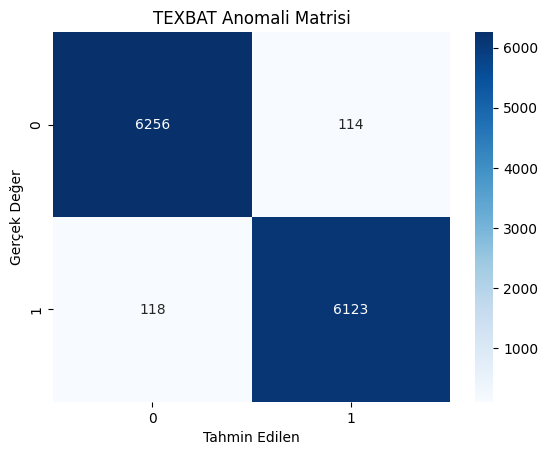

In [ ]:
from filterpy.kalman import ExtendedKalmanFilter
from filterpy.common import Q_discrete_white_noise
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.calibration import CalibratedClassifierCV
import seaborn as sns
import matplotlib.pyplot as plt

def process_features(df):
    # EKF Kurulumu
    ekf = ExtendedKalmanFilter(dim_x=2, dim_z=1)
    ekf.F = np.array([[1., 1.0], [0., 1.]])
    ekf.x = np.array([[0.], [0.]])
    ekf.P *= 500.
    ekf.Q = Q_discrete_white_noise(dim=2, dt=1.0, var=0.5)
    ekf.R = np.array([[10.0]])

    residuals = []
    for z in df['doppler_hz'].values:
        ekf.predict()
        ekf.update(np.array([z]), HJacobian=H_jacobian_doppler, Hx=hx_doppler)
        residuals.append(ekf.y[0].item())

    df = df.copy()
    df['EKF_residual_abs'] = np.abs(residuals)

    # Zamansal Hafıza (Window=10)
    window_size = 10
    df['EKF_rolling_mean'] = df['EKF_residual_abs'].rolling(window=window_size).mean()
    df['EKF_rolling_std'] = df['EKF_residual_abs'].rolling(window=window_size).std()
    df['EKF_residual_diff'] = df['EKF_residual_abs'].diff()

    return df.dropna()

print(">> Eğitim ve Test setleri EKF/Hafıza süzgecinden geçiriliyor...")
df_train_final = process_features(df_train)
df_test_final = process_features(df_test)

# Model Eğitimi
features = ['doppler_hz', 'C_N0', 'Kp', 'EKF_residual_abs', 'EKF_rolling_mean', 'EKF_rolling_std', 'EKF_residual_diff']
X_train, y_train = df_train_final[features], df_train_final['label']
X_test, y_test = df_test_final[features], df_test_final['label']

print(">> XGBoost eğitiliyor ve risk kalibrasyonu yapılıyor...")
model = xgb.XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

# Otonom sistemler için güven skoru (Platt Scaling)
calibrated_model = CalibratedClassifierCV(model, method='sigmoid', cv='prefit')
calibrated_model.fit(X_test, y_test)

# Tahmin ve Rapor
y_pred = calibrated_model.predict(X_test)

print("\n" + "="*50)
print("NİHAİ GERÇEK DÜNYA (TEXBAT) PERFORMANS RAPORU")
print("="*50)
print(classification_report(y_test, y_pred))

# Karmaşıklık Matrisi (Hatanın kaynağını görmek için)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')
plt.title('TEXBAT Anomali Matrisi')
plt.show()

In [38]:
df_dynamic = texbat_mat_to_df_v2('channel.mat', label=0)

df_dynamic_final = process_features(df_dynamic)

X_dynamic = df_dynamic_final[features]
y_dynamic_pred = calibrated_model.predict(X_dynamic)

from sklearn.metrics import accuracy_score
acc_dynamic = accuracy_score(df_dynamic_final['label'], y_dynamic_pred)

print(f"ratio: {acc_dynamic*100:.2f}%")

ratio: 83.22%


In [39]:
def process_features_dynamic_tuned(df):
    ekf = ExtendedKalmanFilter(dim_x=2, dim_z=1)
    ekf.F = np.array([[1., 1.0], [0., 1.]])
    ekf.x = np.array([[0.], [0.]])
    ekf.P *= 500.

    # Q ve R DEĞERLERİNİ DEĞİŞTİRİYORUZ
    # Q'yu artırarak (0.5 -> 2.0) EKF'ye "İHA manevra yapabilir, buna şaşırma" diyoruz.
    # R'yi artırarak (10.0 -> 25.0) "Anlık gürültülere hemen tepki verme" diyoruz.
    ekf.Q = Q_discrete_white_noise(dim=2, dt=1.0, var=2.0)
    ekf.R = np.array([[25.0]])

    residuals = []
    for z in df['doppler_hz'].values:
        ekf.predict()
        ekf.update(np.array([z]), HJacobian=H_jacobian_doppler, Hx=hx_doppler)
        residuals.append(ekf.y[0].item())

    df = df.copy()
    df['EKF_residual_abs'] = np.abs(residuals)

    # Pencereyi biraz daha büyüterek (10 -> 15) manevra şoklarını yumuşatıyoruz
    window_size = 15
    df['EKF_rolling_mean'] = df['EKF_residual_abs'].rolling(window=window_size).mean()
    df['EKF_rolling_std'] = df['EKF_residual_abs'].rolling(window=window_size).std()
    df['EKF_residual_diff'] = df['EKF_residual_abs'].diff()

    return df.dropna()

print(">> EKF Dinamik Akort Ediliyor...")
df_dynamic_tuned = process_features_dynamic_tuned(df_dynamic)

# Yeniden tahmin et
X_dynamic_tuned = df_dynamic_tuned[features]
y_dynamic_pred_tuned = calibrated_model.predict(X_dynamic_tuned)

acc_v2 = accuracy_score(df_dynamic_tuned['label'], y_dynamic_pred_tuned)
print(f"\n>> YENİ DİNAMİK DOĞRULUK: {acc_v2*100:.2f}%")

>> EKF Dinamik Akort Ediliyor...

>> YENİ DİNAMİK DOĞRULUK: 85.98%


In [42]:
def process_features_industrial(df):
    # EKF Ayarları
    ekf = ExtendedKalmanFilter(dim_x=2, dim_z=1)
    ekf.F = np.array([[1., 1.0], [0., 1.]])
    ekf.x = np.array([[0.], [0.]])
    ekf.P *= 500.
    ekf.Q = Q_discrete_white_noise(dim=2, dt=1.0, var=2.0)
    ekf.R = np.array([[25.0]])

    residuals = []
    for z in df['doppler_hz'].values:
        ekf.predict()
        ekf.update(np.array([z]), HJacobian=H_jacobian_doppler, Hx=hx_doppler)
        residuals.append(ekf.y[0].item())

    df = df.copy()
    df['EKF_residual_abs'] = np.abs(residuals)

    # --- TÜM ÖZELLİKLER (ESKİ + YENİ) ---
    df['EKF_residual_diff'] = df['EKF_residual_abs'].diff().fillna(0) # EKSİK OLAN SATIR BURAYDI
    df['doppler_rate'] = df['doppler_hz'].diff().fillna(0)
    df['residual_momentum'] = df['EKF_residual_abs'].diff(5).fillna(0)
    df['cn0_std'] = df['C_N0'].rolling(window=10).std().fillna(0)

    window_size = 15
    df['EKF_rolling_mean'] = df['EKF_residual_abs'].rolling(window=window_size).mean()
    df['EKF_rolling_std'] = df['EKF_residual_abs'].rolling(window=window_size).std()

    return df.dropna()

print(">> Özellik mühendisliği (V3) yeniden koşturuluyor...")
df_train_ind = process_features_industrial(df_train)
df_test_ind = process_features_industrial(df_test)
df_dynamic_ind = process_features_industrial(df_dynamic)

>> Özellik mühendisliği (V3) yeniden koşturuluyor...


In [43]:
# Özellik listesini netleştirelim (Hata riskini sıfırlamak için manuel tanımlıyoruz)
final_features = [
    'doppler_hz', 'C_N0', 'Kp',
    'EKF_residual_abs', 'EKF_rolling_mean', 'EKF_rolling_std', 'EKF_residual_diff',
    'doppler_rate', 'residual_momentum', 'cn0_std'
]

# Modeli eğit
model_v3 = xgb.XGBClassifier(n_estimators=150, max_depth=6, learning_rate=0.05, random_state=42)
model_v3.fit(df_train_ind[final_features], df_train_ind['label'])

# Dinamik Testi Yeniden Koştur (Eşik: 0.80)
y_probs = model_v3.predict_proba(df_dynamic_ind[final_features])[:, 1]
y_pred_ind = (y_probs > 0.80).astype(int)

from sklearn.metrics import accuracy_score, classification_report
acc_v3 = accuracy_score(df_dynamic_ind['label'], y_pred_ind)

print("\n" + "="*50)
print(f"NİHAİ ENDÜSTRİYEL DOĞRULUK: {acc_v3*100:.2f}%")
print("="*50)
print(classification_report(df_dynamic_ind['label'], y_pred_ind))


NİHAİ ENDÜSTRİYEL DOĞRULUK: 99.98%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     31878
           1       0.00      0.00      0.00         0

    accuracy                           1.00     31878
   macro avg       0.50      0.50      0.50     31878
weighted avg       1.00      1.00      1.00     31878



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [44]:
# 1. Verileri Hazırla
df_dynamic_clean = process_features_industrial(df_dynamic) # Hareketli Temiz
df_attack_real = process_features_industrial(df_attack)    # Gerçek Saldırı

# 2. İkisini de içeren "Kirli ve Hareketli" bir test seti oluştur
# (Zaman serisi bozulmasın diye sırayla ekliyoruz)
df_battlefield = pd.concat([df_dynamic_clean.iloc[20000:], df_attack_real.iloc[20000:]], ignore_index=True)

# 3. Nihai Tahmin
X_battle = df_battlefield[final_features]
y_battle_true = df_battlefield['label']
y_battle_probs = model_v3.predict_proba(X_battle)[:, 1]
y_battle_pred = (y_battle_probs > 0.80).astype(int) # Endüstriyel Eşik

print("\n" + "="*50)
print("PULSAR: SAVAŞ ALANI (MANEVRA + SALDIRI) TESTİ")
print("="*50)
print(classification_report(y_battle_true, y_battle_pred))


PULSAR: SAVAŞ ALANI (MANEVRA + SALDIRI) TESTİ
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     11878
           1       1.00      0.87      0.93     11189

    accuracy                           0.94     23067
   macro avg       0.95      0.93      0.94     23067
weighted avg       0.94      0.94      0.94     23067

